In [4]:
import os
from openai import OpenAI

# 配置 agicto API
client = OpenAI(
    api_key=os.environ.get("AGICTO_API_KEY", "sk-7kyRI98oHgH7mlKveOKk86MLAvbgxu3tERptjssFzAgo6Cfr"),
    base_url="https://api.agicto.cn/v1"
)

MODEL = "gpt-4o-mini"

In [5]:
def chat_with_llm(messages, model=MODEL, temperature=0.7, max_tokens=1024):
    """发送消息给 LLM 并获取回复"""
    response = client.chat.completions.create(
        model=model,
        messages=messages,
        temperature=temperature,
        max_tokens=max_tokens
    )
    return response.choices[0].message.content

# 基础测试
messages = [{"role": "user", "content": "你好，请简单介绍下番茄的种植要点。"}]
reply = chat_with_llm(messages)
print(reply)

你好！番茄的种植要点主要包括以下几个方面：

1. **选择品种**：根据气候和市场需求选择合适的番茄品种，如樱桃番茄、牛心番茄等。

2. **土壤准备**：番茄喜欢疏松、肥沃、排水良好的土壤。在种植前进行深翻，添加有机肥料（如腐熟的农家肥或堆肥）以提高土壤肥力。

3. **播种和移植**：可以选择直接播种或育苗移植。育苗时，种子在温暖的环境中发芽，待幼苗长到10-15厘米时可以移植到大田。

4. **光照和温度**：番茄需要充足的阳光，确保每天至少有6-8小时的直射阳光。适宜的生长温度为20-30℃。

5. **浇水管理**：保持土壤湿润，但避免积水。特别是在开花和结果期要适当增加浇水频率。

6. **施肥**：在生长期间定期施用氮、磷、钾等复合肥料，促进植物生长和果实发育。

7. **病虫害防治**：定期检查植株，及时防治虫害和病害。可以选择生物防治或低毒农药。

8. **支撑和修剪**：对于高秧番茄，建议使用支架支撑，以防止倒伏。适时修剪可以促进通风和光照，有利于果实成熟。

9. **采收**：番茄成熟后应及时采收，避免过熟导致果实腐烂。

希望这些要点能帮助你成功种植番茄！如果还有其他问题，欢迎随时问我。


In [6]:
import time

def benchmark_prompt(system_prompt, user_prompt, label=""):
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]
    start = time.time()
    reply = chat_with_llm(messages, temperature=0.3)
    elapsed = time.time() - start
    print(f"\n{'='*60}")
    print(f"【{label}】")
    print(f"耗时: {elapsed:.1f}s")
    print(f"回答:\n{reply}")
    return reply

# ── 实验 1：基础 prompt（无角色设定） ──
benchmark_prompt(
    system_prompt="",
    user_prompt="番茄叶子发黄是什么原因？",
    label="实验1：基础Prompt"
)

# ── 实验 2：角色设定 + 结构化要求 ──
benchmark_prompt(
    system_prompt="你是一位有20年经验的农业植保专家。请用专业但易懂的语言回答农民的病害问题。",
    user_prompt="番茄叶子发黄是什么原因？请从以下方面分析：1. 可能的病害类型 2. 非病害原因（营养、水分等）3. 如何区分 4. 防治建议",
    label="实验2：角色设定+结构化"
)

# ── 实验 3：Few-shot + Chain of Thought ──
benchmark_prompt(
    system_prompt="你是一位农业植保专家。请按以下步骤分析：先观察症状特征，再对比已知病害，最后给出诊断和建议。",
    user_prompt="""请参考以下诊断示例，对新的症状进行分析：

示例1：
- 症状：番茄叶片出现同心轮纹状褐色病斑
- 诊断：早疫病（Alternaria solani）。轮纹状病斑是典型特征。
- 建议：移除病叶，喷施代森锰锌或苯醚甲环唑。

示例2：
- 症状：番茄果实出现水渍状褐色凹陷斑，高湿环境下有白色霉层
- 诊断：晚疫病（Phytophthora infestans）。水渍状斑和白色霉层是关键特征。
- 建议：控制湿度，喷施烯酰吗啉或霜脲氰。

新症状：番茄叶片边缘出现 V 形黄褐色坏死斑，病健交界明显，多从下部叶片开始。
请逐步分析。""",
    label="实验3：Few-shot+逐步推理"
)


【实验1：基础Prompt】
耗时: 9.3s
回答:
番茄叶子发黄可能有多种原因，以下是一些常见的原因及其解决方法：

1. **水分问题**：
   - **过多浇水**：土壤长期湿润会导致根部缺氧，根腐病等问题，从而导致叶子发黄。
   - **缺水**：土壤过于干燥，植物缺水也会导致叶子发黄。

   **解决方法**：保持土壤适度湿润，避免积水和干旱。

2. **营养不足**：
   - **氮素缺乏**：氮是植物生长的重要元素，缺乏时叶子会变黄，尤其是老叶。
   - **其他营养元素缺乏**：如铁、镁等微量元素缺乏也会导致黄叶。

   **解决方法**：施用平衡的肥料，确保植物获得足够的营养。

3. **病虫害**：
   - **病害**：如真菌感染、细菌感染等可能导致叶子变黄。
   - **虫害**：如蚜虫、白粉虱等虫害也可能导致叶子发黄。

   **解决方法**：定期检查植物，发现病虫害后及时处理，可以使用农药或天然驱虫剂。

4. **环境因素**：
   - **温度变化**：极端的温度（过高或过低）会影响植物的生长，导致叶子发黄。
   - **光照不足**：番茄需要充足的阳光，光照不足会导致生长不良和叶子变黄。

   **解决方法**：确保植物生长在适宜的温度和光照条件下。

5. **根系问题**：
   - **根系受损**：如移植时损伤根系，或者土壤紧实导致根系无法正常呼吸。

   **解决方法**：小心处理根系，确保土壤松散，促进根系健康生长。

通过观察植物的生长环境和管理情况，可以找到导致番茄叶子发黄的具体原因，并采取相应的措施进行调整。

【实验2：角色设定+结构化】
耗时: 9.4s
回答:
番茄叶子发黄是一个常见的问题，可能由多种因素引起。下面从几个方面进行分析：

### 1. 可能的病害类型
- **真菌病害**：如灰霉病、白粉病等，通常会导致叶片出现斑点或霉状物，最终导致叶片发黄和枯萎。
- **细菌病害**：如细菌性叶斑病，通常会在叶片上形成水浸状斑点，随着病情发展，叶片会变黄并干枯。
- **病毒病害**：如番茄黄化曲叶病毒，感染后会导致叶片变黄、畸形，且通常伴随生长缓慢。

### 2. 非病害原因（营养、水分等）
- **营养缺乏**：氮、镁、铁等元素缺乏会导致叶片发黄。氮缺乏时，老叶先变黄

'- 症状：番茄叶片边缘出现 V 形黄褐色坏死斑，病健交界明显，多从下部叶片开始。\n\n- 诊断：该症状符合番茄的细菌性叶斑病（Xanthomonas campestris pv. vesicatoria）。V 形坏死斑和明显的病健交界是该病害的典型特征，且通常从下部叶片开始发展。\n\n- 建议：及时移除受感染的叶片，避免病害传播。可喷施铜制剂（如氢氧化铜）或其他适合的细菌性病害防治药剂。同时，注意田间管理，保持良好的通风和适当的灌溉，以减少湿度，降低病害发生的风险。'

In [7]:
# 模拟一次完整的农业咨询对话
messages = [
    {"role": "system", "content": "你是农业植保专家，专门帮助农民诊断和防治作物病害。回答要专业、实用、有依据。"}
]

def multi_turn_chat(user_input):
    messages.append({"role": "user", "content": user_input})
    reply = chat_with_llm(messages, temperature=0.5)
    messages.append({"role": "assistant", "content": reply})
    print(f"你: {user_input}")
    print(f"专家: {reply}\n")
    return reply

# 多轮对话测试
multi_turn_chat("我家的番茄最近叶子开始出现褐色斑点，集中在下部叶片，是怎么回事？")
multi_turn_chat("用什么药比较好？我现在手头有代森锰锌。")
multi_turn_chat("打药的频率应该是多少？")

你: 我家的番茄最近叶子开始出现褐色斑点，集中在下部叶片，是怎么回事？
专家: 番茄叶子出现褐色斑点，尤其是集中在下部叶片，可能是以下几种病害引起的：

1. **灰霉病（Botrytis cinerea）**：
   - 特征：叶片出现水渍状斑点，随后变为褐色，最后可能导致叶片枯萎。
   - 防治：保持良好的通风和光照，避免过度浇水。可以使用含有百菌清、甲基托布津等药剂进行防治。

2. **番茄叶霉病（Alternaria solani）**：
   - 特征：在叶片上出现圆形褐色斑点，斑点周围有黄色晕圈，通常从下部叶片开始。
   - 防治：及时清除病叶，保持田间卫生。可使用含有多菌灵、噻菌铜等药剂进行喷洒。

3. **真菌性叶斑病**：
   - 特征：叶片上出现不规则的褐色斑点，可能伴随有叶片变黄、干枯。
   - 防治：轮作、合理施肥、适时浇水，避免叶片潮湿。使用相关的杀菌剂进行防治。

4. **营养缺乏**：
   - 特征：缺钙、缺镁等营养元素也可能导致叶片出现褐色斑点。
   - 防治：进行土壤检测，适量施用复合肥或特定的微量元素肥料。

建议您首先检查叶片的具体症状，确认病害类型，然后根据病害类型采取相应的防治措施。同时，保持良好的田间管理，及时清理病残体，减少病害传播的机会。

你: 用什么药比较好？我现在手头有代森锰锌。
专家: 代森锰锌是一种广谱的杀菌剂，主要用于防治多种真菌性病害，包括灰霉病和一些叶斑病。对于您提到的番茄叶子出现褐色斑点的情况，代森锰锌可以作为一种有效的防治措施。

### 使用建议：
1. **稀释比例**：根据产品说明书，通常代森锰锌的稀释比例为每升水中加入适量的药剂（具体比例请参考包装说明）。
   
2. **喷施时间**：在早晨或傍晚喷施，避免在高温或强光下喷药，以减少药剂挥发和植物灼伤的风险。

3. **喷施频率**：一般建议每7-10天喷施一次，具体频率可根据病害发展情况调整。连续喷施2-3次后，观察病害变化，必要时再进行后续喷施。

4. **注意事项**：在使用前，最好先在小范围内进行试喷，以观察植物的反应。同时，避免与其他药剂混合使用，除非确认可以兼容。

### 其他辅助措施：
- **田间管理**：保持良好的通风和适当的湿度，及时清理病残体，减少病害传播。
- **营养管理**：确保番茄的营

'打药的频率通常取决于病害的发生情况、环境条件以及所使用药剂的性质。以下是一些常见的建议：\n\n1. **初期防治**：在病害初见时，建议每7天喷施一次，确保药剂能覆盖到所有叶片，特别是下部叶片。\n\n2. **病害严重时**：如果病害发展较快，可以缩短喷施间隔，建议每5-7天喷施一次，直到病害得到控制。\n\n3. **病害控制后**：一旦病害得到控制，可以逐渐延长喷施间隔，通常可以调整为每10-14天喷施一次，以保持预防效果。\n\n4. **季节性考虑**：在潮湿、多雨的天气条件下，病害发生的风险增加，可能需要更频繁地喷药；而在干燥天气条件下，可以适当延长喷药间隔。\n\n### 具体建议：\n- **观察病情**：定期检查作物的健康状况，观察病害的发展趋势，及时调整喷药频率。\n- **轮换使用药剂**：为避免病菌产生抗药性，建议在使用代森锰锌等药剂的同时，结合其他类型的杀菌剂，按照建议的轮换使用频率进行喷施。\n\n总之，打药的频率应根据实际情况灵活调整，确保作物的健康和产量。希望这些建议能帮助您更好地管理番茄病害！'

In [8]:
import matplotlib.pyplot as plt
import matplotlib

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 黑体，Windows一般有
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
/tmp/ipykernel_576/1098332989.py:16: UserWarning: Glyph 22238 (\N{CJK UNIFIED IDEOGRAPH-56DE}) missing from current font.
  plt.tight_layout()
/tmp/ipyk

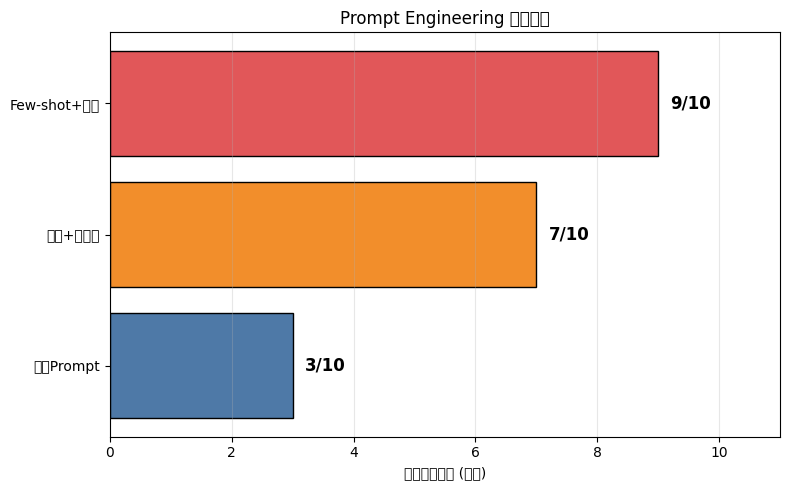

In [9]:
import matplotlib.pyplot as plt

# 记录实验数据
experiments = ["基础Prompt", "角色+结构化", "Few-shot+推理"]
quality_scores = [3, 7, 9]  # 主观评分 1-10，基于回答的专业性和实用性

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(experiments, quality_scores, color=["#4e79a7", "#f28e2b", "#e15759"], edgecolor="black")
for bar, score in zip(bars, quality_scores):
    ax.text(score + 0.2, bar.get_y() + bar.get_height()/2,
            f"{score}/10", va="center", fontsize=12, fontweight="bold")
ax.set_xlabel("回答质量评分 (主观)")
ax.set_title("Prompt Engineering 效果对比")
ax.set_xlim(0, 11)
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("task_a_prompt_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
!apt-get update
!apt-get install -y fonts-noto-cjk

Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy InRelease [270 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]      
Get:5 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3945 kB]
Get:6 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [77.8 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy/multiverse amd64 Packages [266 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy/restricted amd64 Packages [164 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7070 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy/universe amd64 Packages [17.5 MB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1295 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy/main amd64 Packages [1792 kB]    
Get:13 http://archive.ubuntu.com/

In [1]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC']
plt.rcParams['axes.unicode_minus'] = False

In [3]:
import matplotlib
import shutil

shutil.rmtree(matplotlib.get_cachedir(), ignore_errors=True)
print("字体缓存已清理，请重启 Kernel")

字体缓存已清理，请重启 Kernel


In [1]:
import matplotlib.font_manager as fm

for font in fm.fontManager.ttflist:
    if "Noto" in font.name or "CJK" in font.name:
        print(font.name)

Noto Serif CJK JP
Noto Sans CJK JP
Noto Serif CJK JP
Noto Sans CJK JP


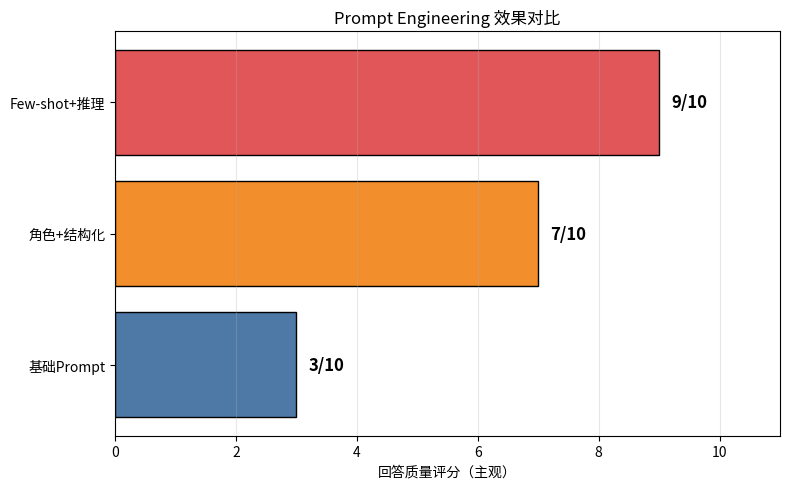

In [2]:
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP']
plt.rcParams['axes.unicode_minus'] = False

# 记录实验数据
experiments = ["基础Prompt", "角色+结构化", "Few-shot+推理"]
quality_scores = [3, 7, 9]  # 主观评分 1-10，基于回答的专业性和实用性

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(
    experiments,
    quality_scores,
    color=["#4e79a7", "#f28e2b", "#e15759"],
    edgecolor="black"
)

for bar, score in zip(bars, quality_scores):
    ax.text(
        score + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{score}/10",
        va="center",
        fontsize=12,
        fontweight="bold"
    )

ax.set_xlabel("回答质量评分（主观）")
ax.set_title("Prompt Engineering 效果对比")
ax.set_xlim(0, 11)
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("task_a_prompt_comparison.png", dpi=150, bbox_inches="tight")
plt.show()